In [1]:
% Comments in MATLAB start with "%"
% Read data
T1083 = readtable("MyMarketNewsSampleAPIv1.1.xlsx", "Sheet", "1083");

Set 'VariableNamingRule' to 'preserve' to use the original column headers as table variable names.

In [2]:
T1084 = readtable("MyMarketNewsSampleAPIv1.1.xlsx", "Sheet", "1084");

Set 'VariableNamingRule' to 'preserve' to use the original column headers as table variable names.

In [3]:
T1085 = readtable("MyMarketNewsSampleAPIv1.1.xlsx", "Sheet", "1085");

Set 'VariableNamingRule' to 'preserve' to use the original column headers as table variable names.

In [4]:
% Extract and compile data
vars = {'Column1_report_date', 'Column1_group', 'Column1_region', ...
        'Column1_price_min', 'Column1_price_max'};
new_vars = {'date', 'group', 'region', 'price_min', 'price_max'};

Tcheese = [ ...
    T1083(:, vars);
    T1084(:, vars);
    T1085(:, vars) ...
];

Tcheese.Properties.VariableNames = new_vars;

Tcheese.date = datetime(Tcheese.date);
Tcheese.group = string(Tcheese.group);
Tcheese.region = string(Tcheese.region);

% Remove all missing values
Tcheese = rmmissing(Tcheese);
Tcheese = Tcheese(Tcheese.group ~= "", :);


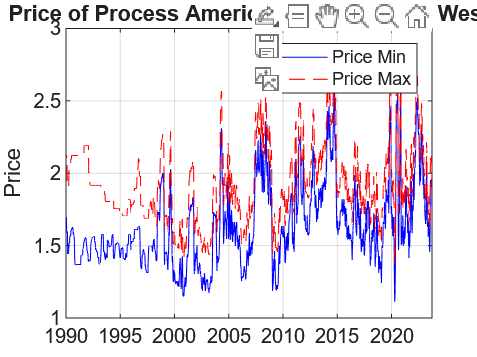

In [5]:
% Plot price for all Process American cheese in the West
figure;
processAmericanCheese = Tcheese(strcmp(Tcheese.group, 'Process American') & strcmp(Tcheese.region, 'West'), :);
plot(processAmericanCheese.date, processAmericanCheese.price_min, 'b-', processAmericanCheese.date, processAmericanCheese.price_max, 'r--');
legend('Price Min', 'Price Max');
ylabel('Price');
title('Price of Process American Cheese in the West');
grid on;


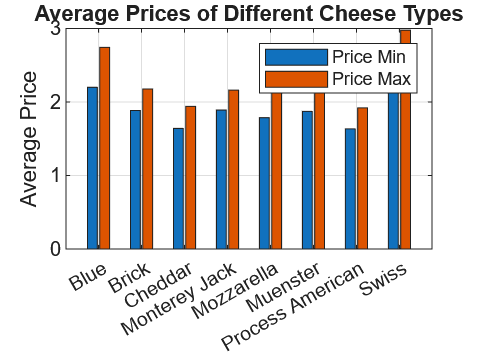

In [6]:
% Plot average price_min/price_max by cheese type

figure;

% Compute mean prices by cheese group
avgPriceMin = varfun(@mean, Tcheese, 'InputVariables', 'price_min', 'GroupingVariables', 'group');
avgPriceMax = varfun(@mean, Tcheese, 'InputVariables', 'price_max', 'GroupingVariables', 'group');

% Extract numeric values
priceMin = avgPriceMin.mean_price_min;
priceMax = avgPriceMax.mean_price_max;

% Extract group names (same order as in avgPriceMin)
groups = avgPriceMin.group;

% Combine into a matrix for bar plot
avgPrice = [priceMin, priceMax];

% Bar plot
bar(categorical(groups), avgPrice);
ylabel('Average Price');
title('Average Prices of Different Cheese Types');
legend('Price Min', 'Price Max');
grid on;


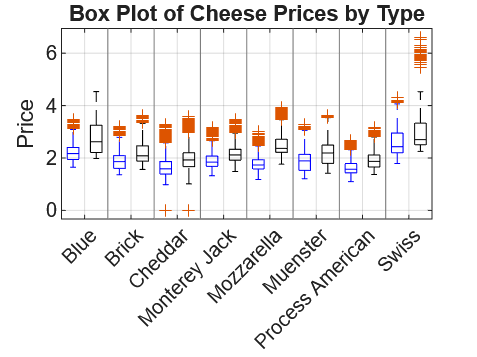

In [7]:
% Make box plots of cheese price by type

figure;

cheeseTypes = unique(Tcheese.group);
cheeseTypes = cheeseTypes(1:end);
nGroups = numel(unique(cheeseTypes));

price = [Tcheese.price_min; Tcheese.price_max];             % stack values
group = [Tcheese.group; Tcheese.group];                     % repeated groups
type = [repmat("Min", height(Tcheese),1); repmat("Max", height(Tcheese),1)];
type = type(:);  % convert to column

boxplot(price, {group, type}, 'Colors', 'bk', 'FactorSeparator', 1);
ax = gca;
ax.XTick = 1.5:2:(2*nGroups-0.5);
ax.XTickLabel = cellstr(cheeseTypes);  % ensure labels match groups
ax.XTickLabelRotation = 45;
% xlabel('Cheese Type');
ylabel('Price');
title('Box Plot of Cheese Prices by Type');
grid on;


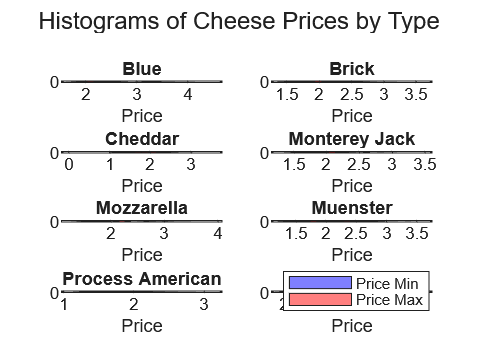

In [8]:
% Make histograms of price_min and price_max by cheese type
figure;

for i = 1:nGroups
    type = cheeseTypes(i);
    data = Tcheese(Tcheese.group == type, :);

    subplot(ceil(nGroups/2), 2, i);  % adjust grid layout
    nbins = 20; % number of bins
    histogram(data.price_min, nbins, 'FaceColor', 'b', 'FaceAlpha', 0.5); % FaceAlpha for transparency
    hold on;
    histogram(data.price_max, nbins, 'FaceColor', 'r', 'FaceAlpha', 0.5);
    hold off;

    xlabel('Price');
    ylabel('Count');
    title(char(type));
end

legend('Price Min','Price Max', 'Location', 'best');
sgtitle('Histograms of Cheese Prices by Type');  % overall title